<a href="https://colab.research.google.com/github/AHMADAMJAD0/Pytorch/blob/main/Hyperparameter_tuning_with_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **asi kaya zrort i kh hummy optuna use kerna pra ?**

Bhai, simple alfaaz mein samjhein to Optuna ka istemal hum tab karte hain jab hum thak jaate hain apne Machine Learning model ki settings ko bar-bar khud badal kar check karne se.

Chalein isko ek aam si misaal (analogy) se samajhte hain:

**Biryani ki Misaal 🍲**
Farz karein aap pehli baar Biryani bana rahe hain. Aapko nahi pata ki kitna namak dalna hai, kitni mirch dalni hai, aur kitni dair dam (cook) par rakhna hai.

Agar aap manually check karenge: Aap ek baar banayenge, chkhenge, phir agli baar thoda namak badhayenge, phir check karenge. Isme buhat time aur mehnat zaya hogi.

Machine Learning mein in settings (namak, mirch) ko hum **Hyperparameters** kehte hain (jaise learning rate, batch size vagera). Aur perfect setting dhoondne ko Hyperparameter Tuning kehte hain.

**Optuna se Pehle Hum Kya Karte Thay?**
Optuna ke aane se pehle log do tareeqe istemal karte thay:

**Grid Search**: Har mumkin setting ko ek ek kar ke check karna. Yeh bilkul waisa hi hai jaise aap 100 dafa alag alag Biryani banayein. Yeh buhat hi zayada slow tareeqa hai.

**Random Search**: Tukka marna (randomly settings try karna). Yeh kabhi chal jata hai, kabhi bilkul flop ho jata hai.

**To Phir Optuna Ki Kaya Zaroorat Padi?** 🤔
Optuna ek Smart Assistant ki tarah kaam karta hai. Iske use karne ki 3 bari wajohat hain:

**Yeh Pichli Galtiyon Se Seekhta Hai** (Smart Optimization): Optuna andha dhund tukkay nahi marta. Agar usne ek setting try ki aur result bura aya, to woh samajh jata hai ki is taraf nahi jaana. Woh un settings ki taraf jata hai jahan result acha aa raha ho.

**Time Bachata Hai (Pruning Feature)**: Agar Optuna koi setting try kar raha hai aur shuru ke 2-3 minutes mein hi model ka result kharab aane lage, to Optuna us trial ko wahin stop (kill) kar deta hai. Woh apna aur aapka time waste nahi karta.

**Likhna Buhat Asan Hai:** Iska code itna simple hota hai ki aap kuch hi lines mein apne model ko auto-pilot par chor sakte hain, aur yeh khud hi best settings dhoond nikalta hai.

**Short Answer:** Optuna hum isliye use karte hain taake hume computer ke aage baith kar khud model ki settings badalni na parein. Hum bas model Optuna ko dete hain, aur woh khud sabse best setting dhoond kar model ki accuracy top par le jata hai.

# **Detailed Breakdown1.**

 **1.Study**

 This is your entire optimization project. If you are trying to maximize the accuracy of a Neural Network, the whole process of running 50 different tests is called a Study.

**2.Trial**

 A single execution of your objective function. In one Trial, Optuna selects specific values (e.g., learning_rate = 0.01, num_layers = 3), trains the model, and gets a score (like 92% accuracy).

 **3.Objective Function**

 This is the function you write that Optuna tries to either maximize (like accuracy/F1-score) or minimize (like error/loss). It takes a trial object as an input and must return a single number.

 **4.Suggest API (Parameter Space)**

 Inside your objective function, you don't give static values. Instead, you "suggest" a range using the Suggest API. Optuna will automatically pick a smart value from this range for each trial:trial.suggest_float('lr', 1e-5, 1e-1, log=True) (for decimal numbers)trial.suggest_int('depth', 2, 32) (for whole numbers)trial.suggest_categorical('optimizer', ['Adam', 'SGD']) (for text options)

**5.Sampler (The Brain)**

The sampler is the algorithm behind the scenes choosing the next set of hyperparameters. Instead of just picking randomly, Optuna uses advanced mathematical samplers (like TPE - Tree-structured Parzen Estimator) to predict which settings will yield a better score based on previous trials.

**6.Pruner (The Judge)**

If a trial starts training and its accuracy is way below the average of previous trials, the Pruner steps in and terminates that trial early. This saves hours of GPU/CPU time because you do not waste resources finishing a doomed run.

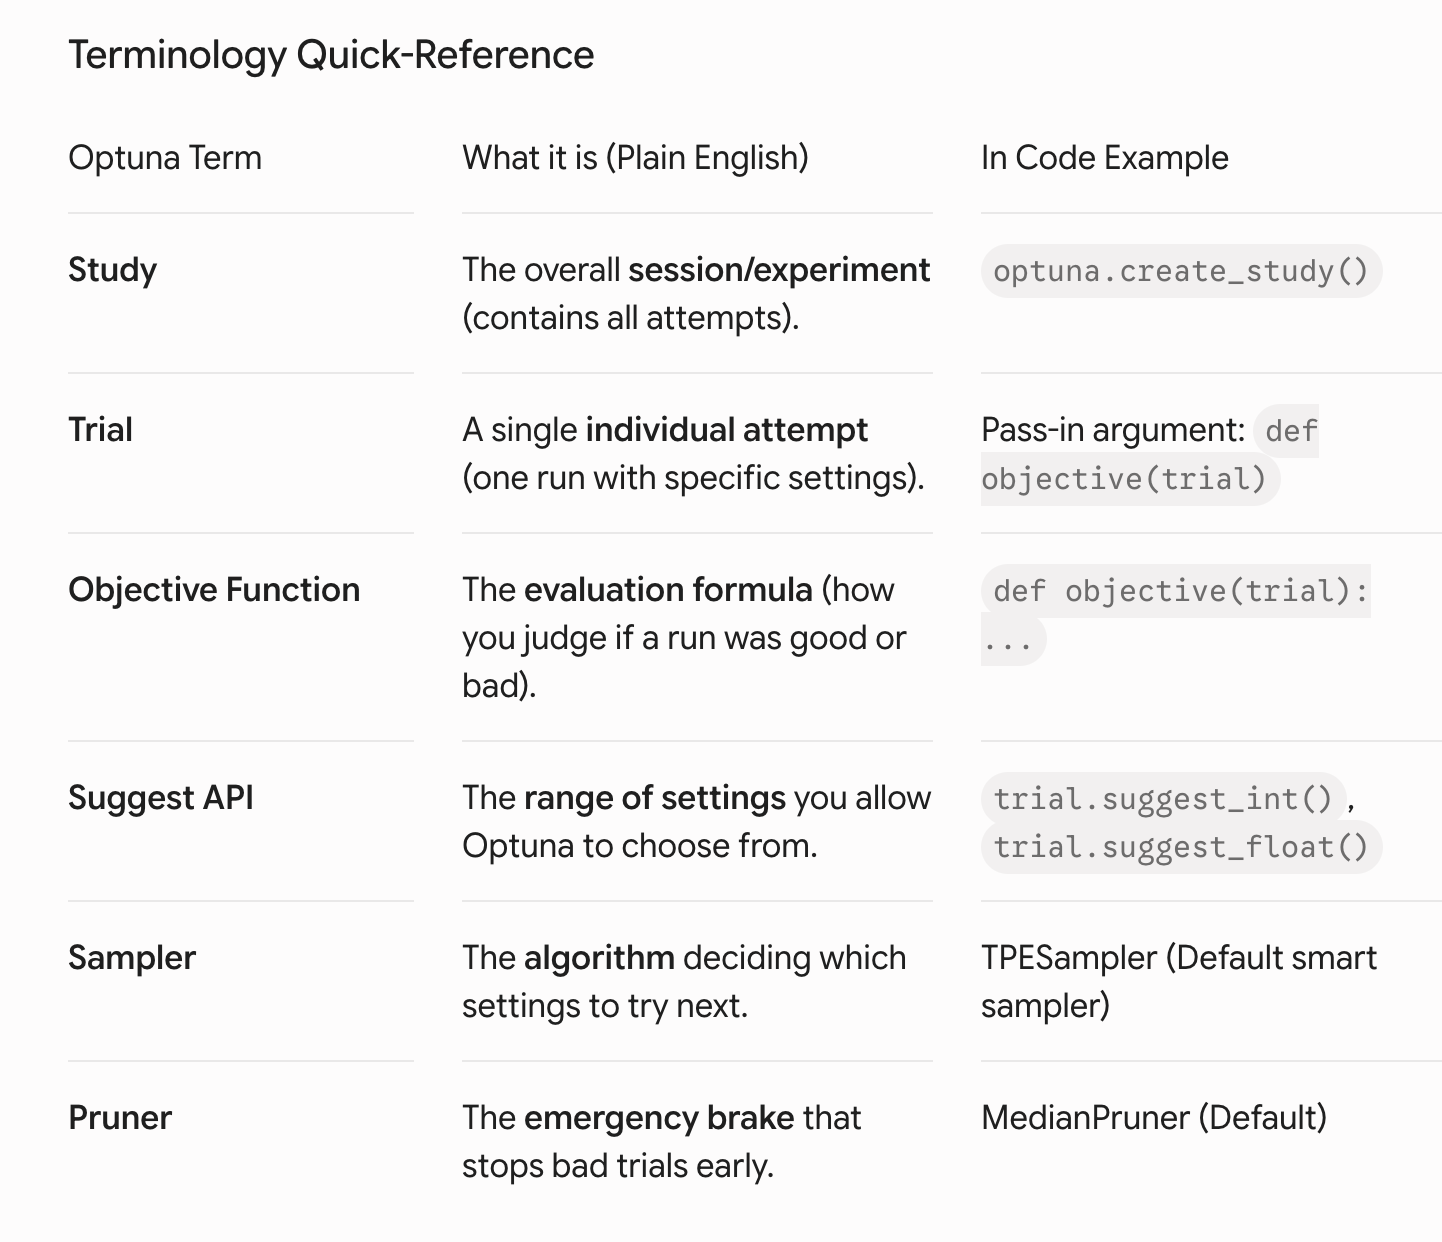

Inki Tafseel (Detailed Explanation)
1. Study (Poora Session)
Yeh aapka poora optimization project hota hai. Jab aap kehte hain ke "Main apne model ko behtar karne ke liye 50 dafa different settings try karunga," to is poore 50 baar ke safar ko Optuna mein Study kehte hain.

2. Trial (Ek Single Koshish)
Study ke andar jab model ek dafa chalta hai (kuch khaas settings ke sath), to us ek baar chalne ko hum Trial kehte hain. Har trial ka aakhir mein ek score aata hai (jaise accuracy = 95%). Agar aapne 50 dafa settings badal kar run kiya, to iska matlab aapne 50 "Trials" kiye.

3. Objective Function (Aapka Target)
Yeh woh Python ka function hota hai jo Optuna ko batata hai ke hume karna kya hai. Kya accuracy ko maximize (sabse zayada) karna hai? Ya error/loss ko minimize (sabse kam) karna hai? Optuna har Trial ke baad is function ka result check karta hai ke score behtar hua ya kharab.

4. Suggest API (Range Batana)
Aap Optuna ko exact value nahi dete, balkay ek range de dete hain ke iske darmiyan se khud hi kuch select karo. Iske liye hum standard code use karte hain:

trial.suggest_int('depth', 2, 32): 2 se 32 ke darmiyan koi bhi poora number chun lo.

trial.suggest_float('lr', 0.001, 0.1): 0.001 se 0.1 ke darmiyan koi decimal point wala number chun lo.

trial.suggest_categorical('optimizer', ['Adam', 'SGD']): Diye gaye options mein se koi ek select kar lo.

5. Sampler (Asli Dimaag)
Yeh Optuna ke peeche chalne wala woh algorithm hai jo andha-dhund tukkay nahi marta. Yeh pichle saare trials ka data dekhta hai aur phir dimaag lga kar agle trial ke liye aisi settings suggest karta hai jahan accuracy barhne ke chances sabse zayada hon.

6. Pruner (Bachat Karne Wala)
Farz karein aapka model train hone mein 1 ghanta leta hai. Ek trial shuru hua aur shuru ke 2 minute mein hi uski accuracy buhat hi gandi aayi. To Pruner us trial ko poora chalne ke bajaye wahin par stop (kill) kar dega. Is se aapka qeemti time aur computer ki power zaya hone se bach jati hai.

In [3]:
! pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.0 MB/s eta 0:00:00


In [4]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd
import numpy as np

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
            'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.shape

(768, 9)

In [6]:
col_with_missing_val = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'] # there are columns which have zero valu 0

In [7]:
df[col_with_missing_val] = df[col_with_missing_val].replace(0,np.nan) # here we are replace 0 to nan value

In [8]:
df.fillna(df.mean() , inplace=True)
print(df.isnull().sum)

<bound method DataFrame.sum of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     DiabetesPedigreeFunction    Age  Outcome  
0                   

In [9]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Training set shape: (537, 8)
Test set shape: (231, 8)


**here we will apply a whole concept of optuna**

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
  n_estimators = trial.suggest_int('n_estimators',50 , 200)
  max_depth = trial.suggest_int('max_depth' , 3 , 20)

  model = RandomForestClassifier(
    n_estimators = n_estimators,
    max_depth = max_depth,
    random_state = 42
)
  score = cross_val_score(model , X_train , y_train , cv = 3 , scoring= 'accuracy').mean()
  return score


In [19]:
study = optuna.create_study(direction = 'maximize' , sampler=optuna.samplers.TPESampler())

 # sampler ka kam hai kh agli kis value ki accuracey nikalni hai ya sampler decide kerta hai
 # TPESampler ya decide kerta hai kh previous output ki base pr kis hyperparameter value tryout kerni hai
study.optimize(objective , n_trials = 50)

[I 2026-07-19 00:45:48,484] A new study created in memory with name: no-name-677d3538-9236-4f6c-bb33-f7db0672ea6a
[I 2026-07-19 00:45:49,866] Trial 0 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 117, 'max_depth': 3}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-07-19 00:45:51,534] Trial 1 finished with value: 0.750465549348231 and parameters: {'n_estimators': 128, 'max_depth': 10}. Best is trial 0 with value: 0.7616387337057727.
[I 2026-07-19 00:45:53,705] Trial 2 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 97, 'max_depth': 9}. Best is trial 2 with value: 0.7653631284916201.
[I 2026-07-19 00:45:55,826] Trial 3 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 176, 'max_depth': 5}. Best is trial 2 with value: 0.7653631284916201.
[I 2026-07-19 00:45:57,039] Trial 4 finished with value: 0.7392923649906891 and parameters: {'n_estimators': 104, 'max_depth': 18}. Best is trial 2 with value: 0.765363128

In [21]:
# print(f"best accuracet",{study.best_trial.value})
# print(f"best hyperparameter",{study.best_trial.params})

print("Best accuracy:", study.best_value)
print("Best parameters:", study.best_params)

Best accuracy: 0.7728119180633147
Best parameters: {'n_estimators': 81, 'max_depth': 3}


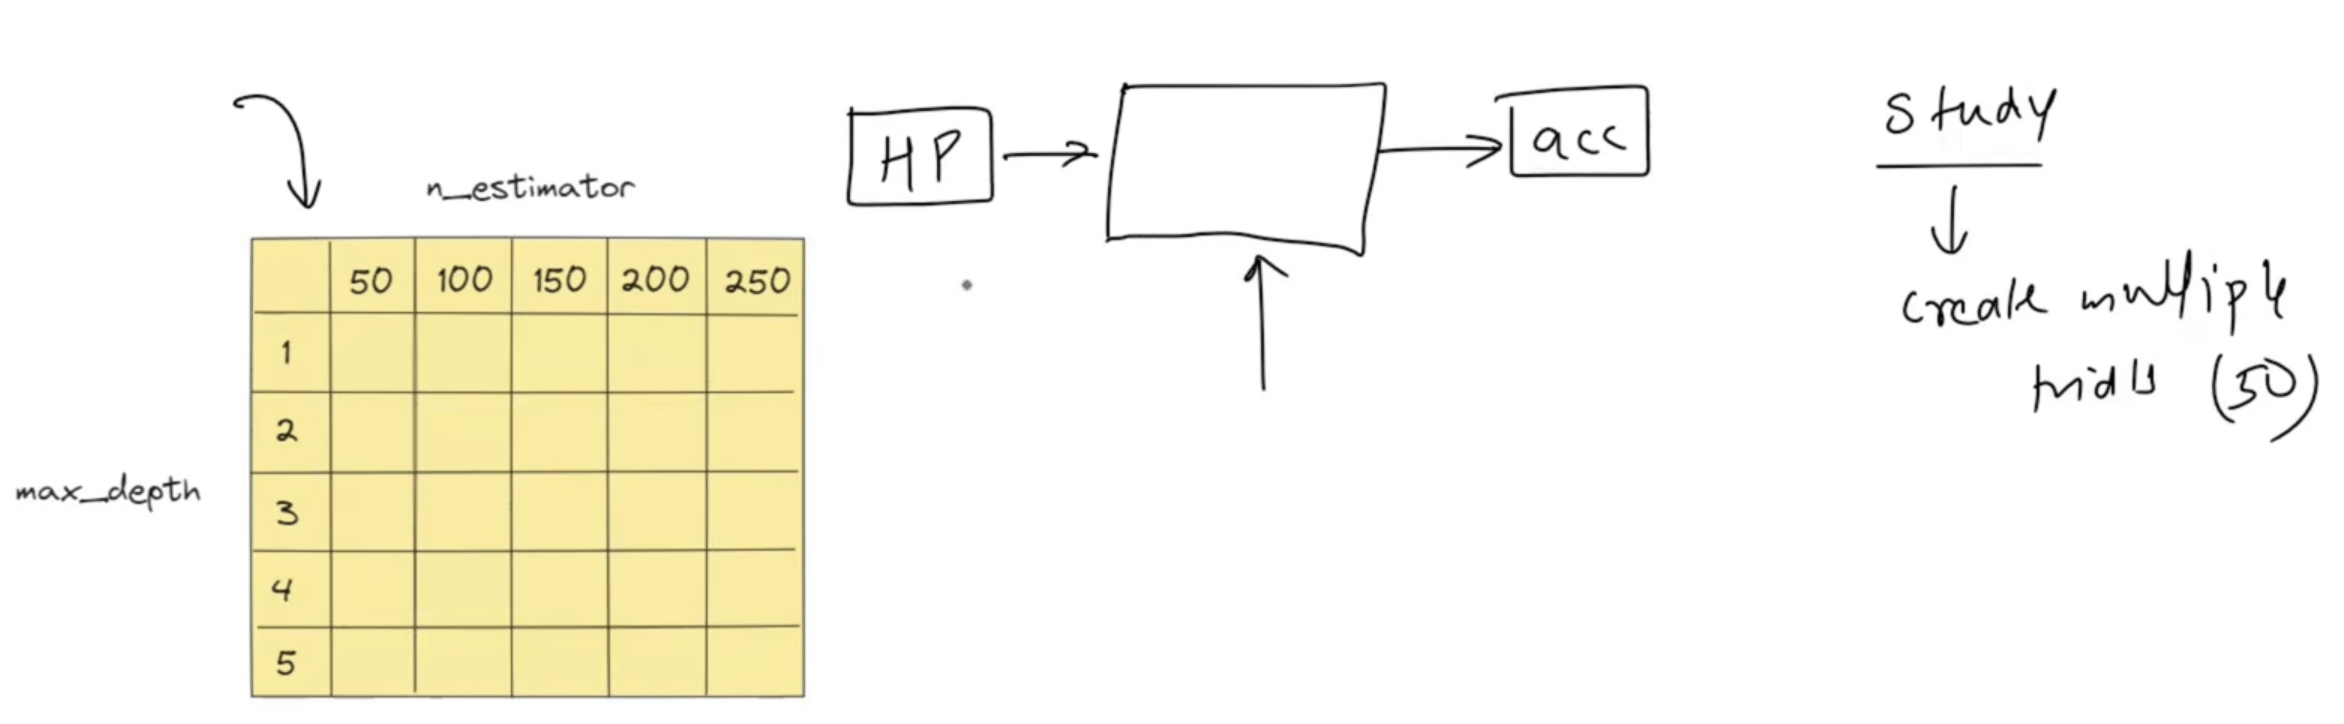

In [12]:
# import optuna
# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler

# # Load dataset
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# columns = [
#     'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
#     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
# ]

# df = pd.read_csv(url, names=columns)

# # These columns can have invalid 0 values
# col_with_missing_val = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# # Replace invalid 0 values with NaN
# df[col_with_missing_val] = df[col_with_missing_val].replace(0, np.nan)

# # Fill missing values with column mean
# df.fillna(df.mean(), inplace=True)

# # Correct way to check missing values
# print(df.isnull().sum())

# # Split into features and target
# X = df.drop('Outcome', axis=1)
# y = df['Outcome']

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.3,
#     random_state=42,
#     stratify=y
# )

# def objective(trial):
#     n_estimators = trial.suggest_int('n_estimators', 50, 200)
#     max_depth = trial.suggest_int('max_depth', 3, 20)

#     model = RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         random_state=42
#     )

#     score = cross_val_score(
#         model,
#         X_train,
#         y_train,
#         cv=3,
#         scoring='accuracy'
#     ).mean()

#     return score

# study = optuna.create_study(
#     direction='maximize',
#     sampler=optuna.samplers.TPESampler(seed=42)
# )

# study.optimize(objective, n_trials=50)

# print("Best accuracy:", study.best_value)
# print("Best parameters:", study.best_params)

[I 2026-07-19 00:36:01,368] A new study created in memory with name: no-name-8f78acb0-3185-40fd-8b6d-8f29514674da


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


[I 2026-07-19 00:36:02,241] Trial 0 finished with value: 0.7374301675977654 and parameters: {'n_estimators': 106, 'max_depth': 20}. Best is trial 0 with value: 0.7374301675977654.
[I 2026-07-19 00:36:03,235] Trial 1 finished with value: 0.7374301675977654 and parameters: {'n_estimators': 160, 'max_depth': 13}. Best is trial 0 with value: 0.7374301675977654.
[I 2026-07-19 00:36:03,663] Trial 2 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 73, 'max_depth': 5}. Best is trial 2 with value: 0.7672253258845437.
[I 2026-07-19 00:36:04,053] Trial 3 finished with value: 0.750465549348231 and parameters: {'n_estimators': 58, 'max_depth': 18}. Best is trial 2 with value: 0.7672253258845437.
[I 2026-07-19 00:36:04,924] Trial 4 finished with value: 0.74487895716946 and parameters: {'n_estimators': 140, 'max_depth': 15}. Best is trial 2 with value: 0.7672253258845437.
[I 2026-07-19 00:36:05,283] Trial 5 finished with value: 0.7430167597765364 and parameters: {'n_estimators

Best accuracy: 0.7709497206703911
Best parameters: {'n_estimators': 75, 'max_depth': 5}


In [22]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters found by Optuna
best_model = RandomForestClassifier(
    **study.best_trial.params,
    random_state=42
)

# Train / fit the model on training data
best_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = best_model.predict(X_test)

# Compare actual test labels with predicted labels
test_accuracy = accuracy_score(y_test, y_pred)

# Print test accuracy
print(f"Test Accuracy with best hyperparameters: {test_accuracy:.2f}")

Test Accuracy with best hyperparameters: 0.74


we used TPESampler which use bayesian search

there a re many types of samplers like

random search

grid search

and more are multple types of search

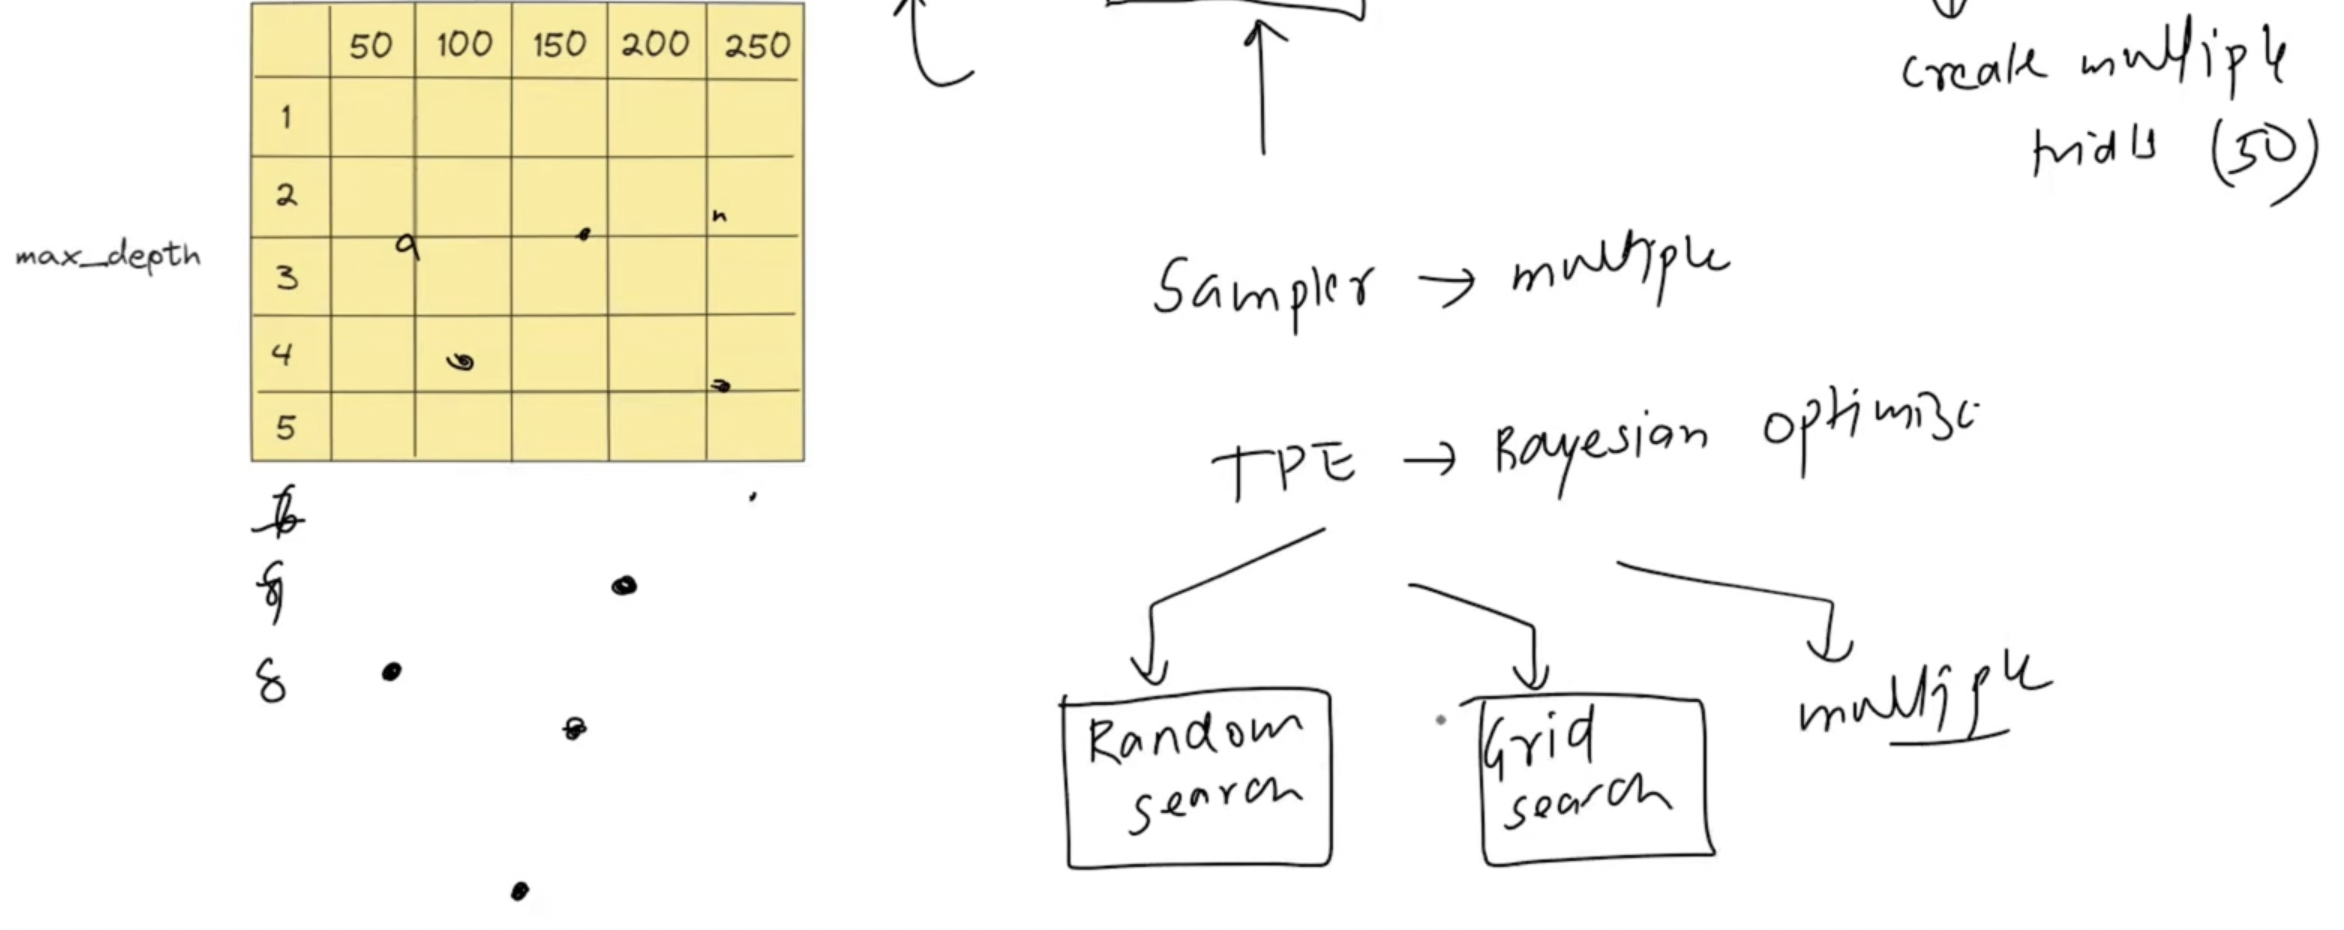



In [25]:
# whenever we have to use optuna we create the objective class  like same who we have created objective class

def objective(trial):
  n_estimators = trial.suggest_int('n_estimators', 50, 200)
  max_depth = trial.suggest_int('max_depth', 5, 20)


  model = RandomForestClassifier(
      n_estimators=n_estimators,
      max_depth=max_depth
  )

  score = cross_val_score(model , X_train , y_train , cv = 3 , scoring= 'accuracy').mean()
  return score



In [27]:
study = optuna.create_study(direction = "maximize" , sampler= optuna.samplers.RandomSampler())
study.optimize(objective , n_trials = 50)

[I 2026-07-19 01:00:28,807] A new study created in memory with name: no-name-2700996e-2dda-4cdf-b162-850e9e2a6759
[I 2026-07-19 01:00:29,766] Trial 0 finished with value: 0.7448789571694601 and parameters: {'n_estimators': 88, 'max_depth': 8}. Best is trial 0 with value: 0.7448789571694601.
[I 2026-07-19 01:00:30,844] Trial 1 finished with value: 0.74487895716946 and parameters: {'n_estimators': 93, 'max_depth': 18}. Best is trial 0 with value: 0.7448789571694601.
[I 2026-07-19 01:00:32,319] Trial 2 finished with value: 0.7467411545623835 and parameters: {'n_estimators': 147, 'max_depth': 11}. Best is trial 2 with value: 0.7467411545623835.
[I 2026-07-19 01:00:33,007] Trial 3 finished with value: 0.756052141527002 and parameters: {'n_estimators': 62, 'max_depth': 5}. Best is trial 3 with value: 0.756052141527002.
[I 2026-07-19 01:00:34,479] Trial 4 finished with value: 0.7486033519553073 and parameters: {'n_estimators': 146, 'max_depth': 13}. Best is trial 3 with value: 0.7560521415270

In [23]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [24]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.GridSampler(search_space)
)

[I 2026-07-19 00:52:41,996] A new study created in memory with name: no-name-23ff8210-86f8-469e-a584-0b64d06f728b
